# Cumulative subducted water, stored water and slab outflux water

Produce grids of cumulative subducted water, stored water and slab outflux water from each contribution of:

- Sediment (bound)
- Crust (bound)
- Lithosphere (bottom)

through time.


### Note: To save the outputs in this notebook once, the chosen hard drive requires at least 500 GB of free storage.

In [1]:
from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
import joblib
import numpy as np
import pygplates
import os
os.environ["DISABLE_GPLATELY_DEV_WARNING"] = "true"
import gplately
import gplately.grids as grids
import gplately.tools as tools
import gplately.ptt as ptt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader as shpreader
import netCDF4
from scipy import ndimage
import pandas as pd
import glob, os
from slabdip import SlabDipper
import numpy.ma as ma
%matplotlib inline
import numpy.ma as ma

from plate_model_manager import PlateModelManager
# plt.style.use('ggplot')

#from pygplates_helper import *

# common variables
extent_globe = [-180, 180, -90, 90]
earth_radius = 6371.0e3
earth_surface_area = 4.0*np.pi*earth_radius**2
tessellation_threshold_radians = np.radians(0.01)

# output grid resolution - should be identical to input grid resolution!
spacingX, spacingY = 0.2, 0.2
resX, resY = int(360./0.2 + 1), int(180./0.2 + 1)
lon_grid = np.arange(extent_globe[0], extent_globe[1]+spacingX, spacingX)
lat_grid = np.arange(extent_globe[2], extent_globe[3]+spacingY, spacingY)
lonq, latq = np.meshgrid(lon_grid,lat_grid)

# reconstruction time steps and spacing
min_time = 0
max_time = 1800
timestep_size = 1

# time array
# reversed (start at max_time, end at min_time)
reconstruction_times = np.arange(max_time, min_time-timestep_size, -timestep_size)




# OUTPUT SAVING TOGGLES
save_output_netcdf = True # !! important
save_output_snapshots = False

# This is to save outputs from the parallelised "water_subducted_and_accreted" routine
save_outputs_to_csv = True


### Ensure all needed output paths are created

In [2]:
save_cumulative_subducted_water = True
save_smoothed_timestep_grid = True
save_smoothed_cumulative_grid = True

# Save the sum of crust + lithosphere + serpentinite
save_mantle_cumulative_subducted_water = True

In [3]:
parent_dir = "./Grids/"

# Lithosphere
lithosphere_top_dir = parent_dir+"Reservoirs/Lithosphere/top/"
lithosphere_bottom_dir = parent_dir+ "Reservoirs/Lithosphere/bottom/"

# Crust
crust_bound_dir = parent_dir+"Reservoirs/Crust/bound/"
crust_pore_dir  = parent_dir+"Reservoirs/Crust/pore/"

# Sediments
sediments_bound_dir = parent_dir+"Reservoirs/Sediment/bound/"
sediments_pore_dir = parent_dir+"Reservoirs/Sediment/pore/"


# this relies on a consistent folder structure - don't meddle!

water_components = [lithosphere_bottom_dir, #lithosphere_top_dir,
                    crust_bound_dir, #crust_pore_dir,
                    sediments_bound_dir,] #sediments_pore_dir]
headers  = ['lithosphere_bottom', #'lithosphere_top',
            'crust_bound', #'crust_pore',
            'sediment_bound',] #'sediment_pore',]
            #'mantle', 'crust', 'sediment']
quantities = ["mean"]#["min", "mean", "max"]

output_cdf_filename = "{}/{}/subducted_water_{}_{}.nc"

### Generate all required output folders

In [11]:
folder_name = "Muller2025" #Name all folders associated with this set of outputs, can rename when re-running later on.
distance_km = 300

# --------------- Everything below here can be kept as-is ----------------
# Directories
output_cumulative_subducted_water_grid_directory = parent_dir+"/cumulative_subducted_water_{}/{}/{}/"
output_smooth_cumulative_subducted_water_grid_directory = parent_dir+"/smoothed_cumulative_subducted_water_{}/{}km/{}/{}/"
output_smoothed_subducted_water_grid_directory = parent_dir+"/smoothed_subducted_water_{}/{}km/{}/{}/"

output_cumulative_stored_water_grid_directory = parent_dir+"/cumulative_stored_water_{}/{}/{}/"
output_smooth_cumulative_stored_water_grid_directory = parent_dir+"/smoothed_cumulative_stored_water_{}/{}km/{}/{}/"
output_smoothed_stored_water_grid_directory = parent_dir+"/smoothed_stored_water_{}/{}km/{}/{}/"

output_smooth_cumulative_slab_outflux_grid_directory = parent_dir+"/smoothed_cumulative_slab_outflux_{}/{}km/{}/{}/"


# Filenames (combined with directories, makes the full absolute filepath)
output_cumulative_subducted_water_filename = output_cumulative_subducted_water_grid_directory+"/cumulative_subducted_water_{}_{}.nc"
output_smooth_cumulative_subducted_water_filename = output_smooth_cumulative_subducted_water_grid_directory+"/cumulative_subducted_water_{}_{}.nc"
smoothed_subducted_water_grid_filename = output_smoothed_subducted_water_grid_directory+"/subducted_water_{}_{}.nc"

output_cumulative_stored_water_filename = output_cumulative_stored_water_grid_directory+"/cumulative_stored_water_{}_{}.nc"
output_smooth_cumulative_stored_water_filename = output_smooth_cumulative_stored_water_grid_directory+"/cumulative_stored_water_{}_{}.nc"
smoothed_stored_water_grid_filename = output_smoothed_stored_water_grid_directory+"/stored_water_{}_{}.nc"

output_smooth_cumulative_slab_outflux_filename = output_smooth_cumulative_slab_outflux_grid_directory+"/cumulative_slab_outflux_{}_{}.nc"

headers_ext = ['lithosphere_bottom', #'lithosphere_top',
            'crust_bound', #'crust_pore',
            'sediment_bound', 'mantle']
for storage in headers_ext:
    for quantity in ['min', 'mean', 'max']:
        os.makedirs(output_cumulative_subducted_water_grid_directory.format(folder_name, storage, quantity), exist_ok=True)
        os.makedirs(output_smooth_cumulative_subducted_water_grid_directory.format(folder_name, distance_km, storage, quantity), exist_ok=True)
        os.makedirs(output_smoothed_subducted_water_grid_directory.format(folder_name, distance_km, storage, quantity), exist_ok=True)
        os.makedirs(output_cumulative_stored_water_grid_directory.format(folder_name, storage, quantity), exist_ok=True)
        os.makedirs(output_smooth_cumulative_stored_water_grid_directory.format(folder_name, distance_km, storage, quantity), exist_ok=True)
        os.makedirs(output_smoothed_stored_water_grid_directory.format(folder_name, distance_km, storage, quantity), exist_ok=True)
        os.makedirs(output_smooth_cumulative_slab_outflux_grid_directory.format(folder_name, distance_km, storage, quantity), exist_ok=True)

Define gplately's `PlateReconstruction` and `PlotTopologies` objects.

In [5]:
# Obtain all rotation files, topology features and static polygons from Muller et al. 2019
pm_manager = PlateModelManager()
Muller2025_model = pm_manager.get_model("Muller2025", data_dir="plate-model-repo")
rotation_model = Muller2025_model.get_rotation_model()
topology_features = Muller2025_model.get_topologies()
static_polygons = Muller2025_model.get_static_polygons()

model = gplately.PlateReconstruction(rotation_model, topology_features, static_polygons)

# Obtain geometry shapefiles with gdownload
coastlines = Muller2025_model.get_coastlines()
continents = Muller2025_model.get_continental_polygons()
COBs = Muller2025_model.get_COBs()

# Call the PlotTopologies object
time = 50 #Ma
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs, time=time)

In [7]:
cell_area = tools.lat_area_function(lat_grid, lat_grid+spacingY, lon_grid.size)
cell_area = np.tile(cell_area.reshape(-1,1), lon_grid.size)

## Make rasters of cumulative subducted water, stored water and slab outflux

If `save_output_netcdf` was set to `True` in Notebooks 2, 3 and 4, masked arrays of total global subducted water, stored water and slab outflux per timestep would have been saved to a netCDF4 grid. All grid nodes with no subducted water, stored water and slab outflux are given NaN entries.

In the cells below, we loop through time to collect the water subducted for each water storage reservoir and quantity. At each time step, we append the current contribution to an array, `cumulative_subducted_water` for a given component and quantity. Every timestep we save the current cumulative subducted water, stored water and slab outflux grid to a netcdf file.

To make this process faster, it is performed using parallelisation with `joblib`. The process is made more memory-friendly by partitioning the time array (and thus the parallel tasks) into groups of times. 

In [8]:
# Define water quantities
quantities = ["min", "mean", "max"]

# Define path to the SUBDUCTED WATER contributions per timestep
def get_subducted_water_grid_filename(c, quantity, reconstruction_time):
    subducted_water_grid_filename = water_components[c]+"{}/subducted_water_{}_{}.nc".format(
        quantity, headers[c].split('_')[0], reconstruction_time
    )
    return subducted_water_grid_filename

def get_stored_water_grid_filename(c, quantity, reconstruction_time):
    stored_water_grid_filename = water_components[c]+"{}/stored_water_{}_{}.nc".format(
        quantity, headers[c].split('_')[0], reconstruction_time
    )
    return stored_water_grid_filename

### Function to smooth subducted water, stored water and slab outflux contribution grids with `scipy.ndimage`'s `fourier_gaussian()` filter
...which we access from an outsourced utility script `fft_gaussian_filter.py` in the `/utils/` directory.

In [10]:
if save_smoothed_timestep_grid:
    
    import sys
    sys.path.insert(0, './utils/')

    import fft_gaussian_filter as fft_gaussian_filter_script

    def gaussian_smooth_grid(data, distance_km):
   
        """ Smooth grids using a Gaussian. 
        If input grid comes with a mask, all masked values are retained. 
        """
        mask = np.isnan(data)
        smoothed_grid = fft_gaussian_filter_script.fft_gaussian_filter(data, distance_km)
        smoothed_grid[mask] = np.nan
        return smoothed_grid

Select a Gaussian filter width (km) and produce a save directory for all cumulative grids with this smoothing filter width.

### Define functions to accumulate grids in parallel, save to netCDF in a single core 

In [12]:
def accumulate_subducted_water(mode, c, component, reconstruction_time, distance_km=300):
    """Function to read water contribution plots for the given component and time, 
    smooth it, then return the smoothed piecewise grid. 
    """
    # Store cumulative SUBDUCTED WATER from the grids in a numpy array
    subducted_water_components = np.zeros((3, resY, resX))
    smoothed_subducted_water_components = np.zeros((3, resY, resX))

    for i, quantity in enumerate(quantities):

        # Read the masked SUBDUCTED WATER contribution array for the current time
        if mode == 'subduction':
            subducted_water_filename = get_subducted_water_grid_filename(c, quantity, reconstruction_time)
            current_time_grid = grids.read_netcdf_grid(subducted_water_filename)
        elif mode == "stored":
            stored_water_filename = get_stored_water_grid_filename(c, quantity, reconstruction_time)
            current_time_grid = grids.read_netcdf_grid(stored_water_filename)
            
        # Get the data array, and fill all NaNs with 0s.
        current_time_grid = np.nan_to_num(current_time_grid.data)
        current_time_grid_filled = grids.fill_raster(current_time_grid)
        subducted_water_components[i] = current_time_grid_filled

        # If the user wants the smoothed piecewise grids to be returned,
        if save_smoothed_timestep_grid:
            if mode == 'subduction':

                # Define the filename for saving the smoothed grids
                smoothed_filename = smoothed_subducted_water_grid_filename.format(
                    distance_km, component, quantity, component.lower(), reconstruction_time
                )
            elif mode == "stored":
                # Define the filename for saving the smoothed grids
                smoothed_filename = smoothed_stored_water_grid_filename.format(
                    distance_km, component, quantity, component.lower(), reconstruction_time
                )
                
            # Smooth the grids
            smoothed_current_time_grid = gaussian_smooth_grid(
                current_time_grid_filled,
                distance_km=distance_km
            )
            # Read in the smoothed grid, fill the raster, and return
            smoothed_current_time_grid_filled = grids.fill_raster(smoothed_current_time_grid)
            smoothed_subducted_water_components[i] += smoothed_current_time_grid_filled
            
            # Create a mask for the interpolated grid - all values with 0s need to have an equivalent
            # mask value of NaN. 
            smoothed_current_time_grid_filled_masked = ma.masked_array(smoothed_current_time_grid_filled)
            smoothed_current_time_grid_filled_masked = ma.masked_values(smoothed_current_time_grid_filled_masked, 0.0)
            smoothed_current_time_grid_filled_masked.fill_value = np.nan
            
            current_subducted_water_smoothed = np.ma.array(
                    smoothed_subducted_water_components[i],
                    mask = smoothed_current_time_grid_filled_masked.mask,
                    fill_value=np.nan
                )
            
            grids.write_netcdf_grid(
                smoothed_filename,
                current_subducted_water_smoothed
            )

    if save_smoothed_timestep_grid:
        return subducted_water_components, reconstruction_time, smoothed_current_time_grid_filled, smoothed_filename
    else:
        return subducted_water_components, reconstruction_time

        
def accumulate_smoothed_mantle_grids(mode, reconstruction_time, distance_km=300):
    """A function to make mantle grids, ie add lithosphere, crust and serpentinite over 1 Myr
    """
    # Store cumulative SUBDUCTED WATER from the grids in a numpy array
    smoothed_subducted_water_components = np.zeros((3, resY, resX))

    for i, quantity in enumerate(quantities):
        # Add Lithosphere bottom, Lithosphere top, Crust bound, Crust pore, Sediment bound, Sediment pore
        for c, component in enumerate(['lithosphere_bottom','crust_bound','sediment_bound']):

            if mode == "subduction":
                subducted_water_filename = smoothed_subducted_water_grid_filename.format(
                    distance_km, component, quantity, component.lower(), reconstruction_time
                )
                current_time_grid = grids.read_netcdf_grid(subducted_water_filename)
            elif mode == "stored":
                stored_water_filename = smoothed_stored_water_grid_filename.format(
                    distance_km, component, quantity, component.lower(), reconstruction_time
                )
                current_time_grid = grids.read_netcdf_grid(stored_water_filename)
                
            # Get the data array, and fill all NaNs with 0s.
            current_time_grid = np.nan_to_num(current_time_grid.data)
            current_time_grid_filled = grids.fill_raster(current_time_grid)

            # For the current time, we have a 3 by resY by resX grid. Each dimension in
            # axis 0 is the sum of all crust, serpentinite and lithosphere in the 
            # min, mean and max (respectively)
            smoothed_subducted_water_components[i] += current_time_grid_filled

    return smoothed_subducted_water_components

## Accumulate grids in parallel...

This cell can get memory-intensive. We can relieve memory pressure by setting `time_splitter_integer` to a smaller value. It can be 0, or negative. The smaller the value, the smaller the chunks of timesteps used for accumulation.

# Cumulative subducted water
Loop through component/reservoir and quantity

In [13]:
time_splitter_integer = -5

In [14]:
mode = "subduction"

with Parallel(n_jobs=-3, verbose=1) as parallel:
    cumulative_subducted_water = np.zeros((len(headers), 3, resY, resX))
    smoothed_cumulative_subducted_water = np.zeros((len(headers), 3, resY, resX))
    total_smoothed_cumulative_mantle = np.zeros((3, resY, resX))
    
    # Split the time array into groups of timesteps
    split_times = np.array_split(reconstruction_times, cpu_count() - time_splitter_integer)
    
    # Start counting current time from min_time
    curr_time = min_time
    
    # Loop through each time array. get a group of SUBDUCTED WATER contributions
    for times in split_times:
        for c, component in enumerate(headers):
            
            print("Accumulating {} grids from {} to {}Ma...".format(component, times[0], times[-1]))

            # Read the timewise contributions from this batch of times and smooth them. 
            results = parallel(delayed(accumulate_subducted_water)(
                mode,
                c,
                component, 
                time,
                distance_km=distance_km
            ) 
               for time in times
            )
            
            results = np.array(results, dtype=object)
            # Remember the times that were accumulated in the parallelised batch as this can be mixed/non-ordered in parallel
            water_subducted = results[:,0]
            curr_times = results[:,1]
            
            if save_smoothed_timestep_grid:
                print("Smoothed {} grids from {} to {}Ma, saving grids now...".format(component, times[0], times[-1]))
                smoothed_water_subducted = results[:,2]

            # For each time index and SUBDUCTED WATER piecewise grid in the current result array,
            for t, subducted_water_components in enumerate(water_subducted):
                
                # We have one array per timestep with 1st dimension being component then 2nd dimension being min, mean and max. 
                # Accumulate the current component up to the most recent time.
                if save_cumulative_subducted_water:
                    cumulative_subducted_water[c] += subducted_water_components 
                
                # Repeat for the smoothed SUBDUCTED WATER piecewise grids if saving smoothed grids. 
                if save_smoothed_cumulative_grid:
                    smoothed_cumulative_subducted_water[c] += smoothed_water_subducted[t]
                    
                # Loop through each quantity
                for q, quantity in enumerate(quantities):
                    
                    # Save the smoothed cumulative SUBDUCTED WATER grid. 
                    if save_smoothed_cumulative_grid:
                        
                        # Make the mask
                        smoothed_cumulative_subducted_water_curr = ma.masked_array(smoothed_cumulative_subducted_water[c,q])
                        smoothed_cumulative_subducted_water_curr = ma.masked_values(smoothed_cumulative_subducted_water_curr, 0.0)
                        smoothed_cumulative_subducted_water_curr.fill_value = np.nan

                        current_smoothed_cumulative_subducted_water = np.ma.array(
                                smoothed_cumulative_subducted_water[c,q],
                                mask = smoothed_cumulative_subducted_water_curr.mask,
                                fill_value=np.nan
                            )
                        
                        gplately.grids.write_netcdf_grid(
                            output_smooth_cumulative_subducted_water_filename.format( 
                                distance_km,
                                component, 
                                quantity, 
                                component.lower(), 
                                curr_times[t]
                            ), 
                            current_smoothed_cumulative_subducted_water
                        )


        # Need a separate section for mantle as we are adding three components together. 
        if save_mantle_cumulative_subducted_water:

            print("Summing mantle grids (lithosphere + crust + sediment) from {} to {}Ma...".format(times[0], times[-1]))
            mantle_results = parallel(delayed(accumulate_smoothed_mantle_grids)(mode, time, distance_km) for time in times)
            mantle_results_arr = np.array(mantle_results, dtype=object)
            mantle_cumulative_results = mantle_results_arr[:,0]
            
            print("Saving mantle grids (lithosphere + crust + sediment) from {} to {}Ma...".format(times[0], times[-1]))
            
            for t, curr_time_mantle_water in enumerate(mantle_cumulative_results):
                
                curr_time_mantle_water = curr_time_mantle_water.astype(dtype=float)
                total_smoothed_cumulative_mantle += curr_time_mantle_water
                
                for q, quantity in enumerate(quantities):
                    
                    current_mantle = total_smoothed_cumulative_mantle[q,:]
                    current_mantle_filled = grids.fill_raster(current_mantle)

                    # Save the smoothed cumulative SUBDUCTED WATER grid. 
                    gplately.grids.write_netcdf_grid(
                        output_smooth_cumulative_subducted_water_filename.format(
                            distance_km,
                            "Mantle", 
                            quantity, 
                            "Mantle".lower(), 
                            times[t]
                        ), 
                        current_mantle_filled
                    )

                                

Accumulating lithosphere_bottom grids from 1800 to 1680Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:  1.1min finished


Smoothed lithosphere_bottom grids from 1800 to 1680Ma, saving grids now...
Accumulating crust_bound grids from 1800 to 1680Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:  1.2min finished


Smoothed crust_bound grids from 1800 to 1680Ma, saving grids now...
Accumulating sediment_bound grids from 1800 to 1680Ma...


...

Smoothed crust_bound grids from 119 to 0Ma, saving grids now...
Accumulating sediment_bound grids from 119 to 0Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   53.2s finished


Smoothed sediment_bound grids from 119 to 0Ma, saving grids now...
Summing mantle grids (lithosphere + crust + sediment) from 119 to 0Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   31.7s finished


Saving mantle grids (lithosphere + crust + sediment) from 119 to 0Ma...


# Cumulative stored water
Loop through component/reservoir and quantity

In [15]:
mode = "stored"
distance_km = 300
save_cumulative_stored_water = True
save_mantle_cumulative_stored_water = True
save_smoothed_cumulative_grid = True

with Parallel(n_jobs=-3, verbose=1) as parallel:
    cumulative_stored_water = np.zeros((len(headers), 3, resY, resX))
    smoothed_cumulative_stored_water = np.zeros((len(headers), 3, resY, resX))
    total_smoothed_cumulative_mantle = np.zeros((3, resY, resX))
    
    # Split the time array into groups of timesteps
    split_times = np.array_split(reconstruction_times, cpu_count() - time_splitter_integer)
    
    # Start counting current time from min_time
    curr_time = min_time
    
    # Loop through each time array. get a group of STORED WATER contributions
    for times in split_times:
        for c, component in enumerate(headers):
            
            print("Accumulating {} grids from {} to {}Ma...".format(component, times[0], times[-1]))

            # Read the timewise contributions from this batch of times and smooth them. 
            results = parallel(delayed(accumulate_subducted_water)(
                mode,
                c,
                component, 
                time,
                distance_km=distance_km
            ) 
               for time in times
            )
            
            results = np.array(results, dtype=object)
            # Remember the times that were accumulated in the parallelised batch as this can be mixed/non-ordered in parallel
            water_stored = results[:,0]
            curr_times = results[:,1]
            
            if save_smoothed_timestep_grid:
                print("Smoothed {} grids from {} to {}Ma, saving grids now...".format(component, times[0], times[-1]))
                smoothed_water_stored = results[:,2]

            # For each time index and STORED WATER piecewise grid in the current result array,
            for t, stored_water_components in enumerate(water_stored):
                
                # We have one array per timestep with 1st dimension being component then 2nd dimension being min, mean and max. 
                # Accumulate the current component up to the most recent time.
                if save_cumulative_stored_water:
                    cumulative_stored_water[c] += stored_water_components 
                
                # Repeat for the smoothed STORED WATER piecewise grids if saving smoothed grids. 
                if save_smoothed_cumulative_grid:
                    smoothed_cumulative_stored_water[c] += smoothed_water_stored[t]
                    
                # Loop through each quantity
                for q, quantity in enumerate(quantities):
                    
                    # Save the raw cumulative STORED WATER grid. 
                    if save_smoothed_cumulative_grid:
                        
                        # Make the mask
                        smoothed_cumulative_stored_water_curr = ma.masked_array(smoothed_cumulative_stored_water[c,q])
                        smoothed_cumulative_stored_water_curr = ma.masked_values(smoothed_cumulative_stored_water_curr, 0.0)
                        smoothed_cumulative_stored_water_curr.fill_value = np.nan

                        current_smoothed_cumulative_stored_water = np.ma.array(
                                smoothed_cumulative_stored_water[c,q],
                                mask = smoothed_cumulative_stored_water_curr.mask,
                                fill_value=np.nan
                            )
                        
                        gplately.grids.write_netcdf_grid(
                            output_smooth_cumulative_stored_water_filename.format( 
                                distance_km,
                                component, 
                                quantity, 
                                component.lower(), 
                                curr_times[t]
                            ), 
                            current_smoothed_cumulative_stored_water
                        )


        # Need a separate section for mantle as we are adding three components together. 
        if save_mantle_cumulative_stored_water:

            print("Summing mantle grids (lithosphere + crust + sediment) from {} to {}Ma...".format(times[0], times[-1]))
            mantle_results = parallel(delayed(accumulate_smoothed_mantle_grids)(mode, time, distance_km) for time in times)
            mantle_results_arr = np.array(mantle_results, dtype=object)
            mantle_cumulative_results = mantle_results_arr[:,0]
            
            print("Saving mantle grids (lithosphere + crust + sediment) from {} to {}Ma...".format(times[0], times[-1]))
            
            for t, curr_time_mantle_water in enumerate(mantle_cumulative_results):
                
                curr_time_mantle_water = curr_time_mantle_water.astype(dtype=float)
                total_smoothed_cumulative_mantle += curr_time_mantle_water
                
                for q, quantity in enumerate(quantities):
                    
                    current_mantle = total_smoothed_cumulative_mantle[q,:]
                    current_mantle_filled = grids.fill_raster(current_mantle)

                    # Save the smoothed cumulative STORED WATER grid. 
                    gplately.grids.write_netcdf_grid(
                        output_smooth_cumulative_stored_water_filename.format(
                            distance_km,
                            "Mantle", 
                            quantity, 
                            "Mantle".lower(), 
                            times[t]
                        ), 
                        current_mantle_filled
                    )


Accumulating lithosphere_bottom grids from 1800 to 1680Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   23.1s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:   57.9s finished


Smoothed lithosphere_bottom grids from 1800 to 1680Ma, saving grids now...
Accumulating crust_bound grids from 1800 to 1680Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:   48.5s finished


Smoothed crust_bound grids from 1800 to 1680Ma, saving grids now...
Accumulating sediment_bound grids from 1800 to 1680Ma...


...

Smoothed crust_bound grids from 119 to 0Ma, saving grids now...
Accumulating sediment_bound grids from 119 to 0Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   14.4s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   43.2s finished


Smoothed sediment_bound grids from 119 to 0Ma, saving grids now...
Summing mantle grids (lithosphere + crust + sediment) from 119 to 0Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   25.7s finished


Saving mantle grids (lithosphere + crust + sediment) from 119 to 0Ma...


# Cumulative slab outflux

In [16]:
def make_slab_outflux(component, time, distance_km, quantity):
    subd_Grd = gplately.Raster(
        output_smooth_cumulative_subducted_water_filename.format( 
            distance_km,
            component, 
            quantity, 
            component.lower(), 
            time)
    ).data
    storage_Grd = gplately.Raster(
        output_smooth_cumulative_stored_water_filename.format( 
            distance_km,
            component, 
            quantity, 
            component.lower(), 
            time)
        ).data
    outflux_grd = subd_Grd - storage_Grd
    
    gplately.grids.write_netcdf_grid(
        output_smooth_cumulative_slab_outflux_filename.format( 
            distance_km,
            component, 
            quantity, 
            component.lower(), 
            time),
        outflux_grd
    )
    return

In [17]:
output_smooth_cumulative_subducted_water_filename.format( 
            distance_km,
            component, 
            quantity, 
            component.lower(), 
            time)

'/Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Cao_etal_2024/H2O/Grids//smoothed_cumulative_subducted_water_Muller2025/300km/sediment_bound/max//cumulative_subducted_water_sediment_bound_50.nc'

### Mantle - slab outflux

In [18]:
with Parallel(n_jobs=-3, verbose=1) as parallel:
    
    # Split the time array into groups of timesteps
    split_times = np.array_split(reconstruction_times, cpu_count() - time_splitter_integer)
    
    # Start counting current time from min_time
    curr_time = min_time
    
    # Loop through each time array. get a group of STORED WATER contributions
    for times in split_times:
        for c, component in enumerate(['mantle']):
            
            print("Accumulating {} slab outflux grids from {} to {}Ma...".format(component, times[0], times[-1]))

            # Read the timewise contributions from this batch of times and smooth them. 
            results = parallel(delayed(make_slab_outflux)(
                component, 
                time,
                distance_km,
                'mean'
            ) 
               for time in times
            )

Accumulating mantle slab outflux grids from 1800 to 1680Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:   30.8s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating mantle slab outflux grids from 1679 to 1560Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   35.5s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating mantle slab outflux grids from 1559 to 1440Ma...


...

[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:  1.1min finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating mantle slab outflux grids from 239 to 120Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:  1.1min finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating mantle slab outflux grids from 119 to 0Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:  1.2min finished


### Crust bound, lithosphere bottom and sediment bound - slab outflux

In [23]:
with Parallel(n_jobs=-3, verbose=1) as parallel:
    
    # Split the time array into groups of timesteps
    split_times = np.array_split(reconstruction_times, cpu_count() - time_splitter_integer)
    
    # Start counting current time from min_time
    curr_time = min_time
    
    # Loop through each time array. get a group of STORED WATER contributions
    for times in split_times:
        for c, component in enumerate(['crust_bound', 'lithosphere_bottom', 'sediment_bound']):
            
            print("Accumulating {} slab outflux grids from {} to {}Ma...".format(component, times[0], times[-1]))

            # Read the timewise contributions from this batch of times and smooth them. 
            results = parallel(delayed(make_slab_outflux)(
                component, 
                time,
                distance_km,
                'mean'
            ) 
               for time in times
            )

Accumulating crust_bound slab outflux grids from 1800 to 1680Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:   40.6s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating lithosphere_bottom slab outflux grids from 1800 to 1680Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:   37.2s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating sediment_bound slab outflux grids from 1800 to 1680Ma...


...

[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:  1.7min finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating lithosphere_bottom slab outflux grids from 119 to 0Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:  1.6min finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Accumulating sediment_bound slab outflux grids from 119 to 0Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:   29.4s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:  1.5min finished


# Plots
### Subducted mantle water

/var/folders/ry/3sftjhts50x0vr1cmqhbw1z40000gp/T/ipykernel_13436/49170099.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


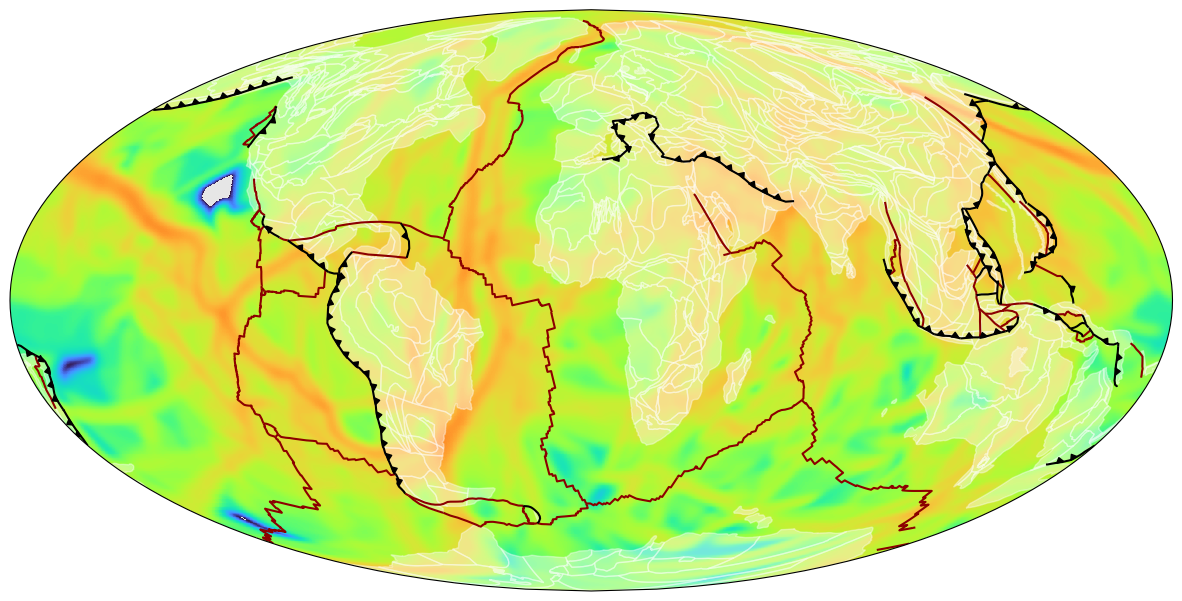

In [27]:
quantity = "mean"
reconstruction_time = 0
sample_grid = gplately.Raster(

    output_smooth_cumulative_subducted_water_filename.format(
        distance_km,
        "Mantle", 
        quantity, 
        "Mantle".lower(), 
        reconstruction_time
    )
)

import copy 

proj = ccrs.Mollweide()
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111, projection=proj)
ax.set_global()

ax.imshow(np.array([[0.9,0.9],[0.9,0.9]]), extent=[-180,180,-180,180], cmap='gray', vmin=0, vmax=1,
          transform=ccrs.PlateCarree(), zorder=0)

data = sample_grid.data*1e6

lognorm_cmap = copy.copy(matplotlib.cm.get_cmap('turbo'))
lognorm_cmap.set_under(color='w', alpha=0)
im = ax.imshow(data, extent=extent_globe, origin='lower', cmap=lognorm_cmap, norm=mcolors.LogNorm(vmin=1e1, vmax=1e6), 
               transform=ccrs.PlateCarree(), interpolation='nearest')

gplot.time = reconstruction_time
# add_continents(ax,  facecolor='0.7', zorder=0)
gplot.plot_continents(ax, facecolor='w', edgecolor='w', alpha=0.4, zorder=2)
gplot.plot_ridges(ax, color='DarkRed', linewidth=1.5, zorder=2)
gplot.plot_transforms(ax, color='DarkRed', linewidth=1.5, zorder=2)
# add_quiver(ax, reconstruction_time, color='k', alpha=0.33, zorder=3)
gplot.plot_trenches(ax, color='k', zorder=2)
gplot.plot_subduction_teeth(ax, color='k', zorder=2)

### Subducted crust bound water

/var/folders/ry/3sftjhts50x0vr1cmqhbw1z40000gp/T/ipykernel_13436/709825186.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


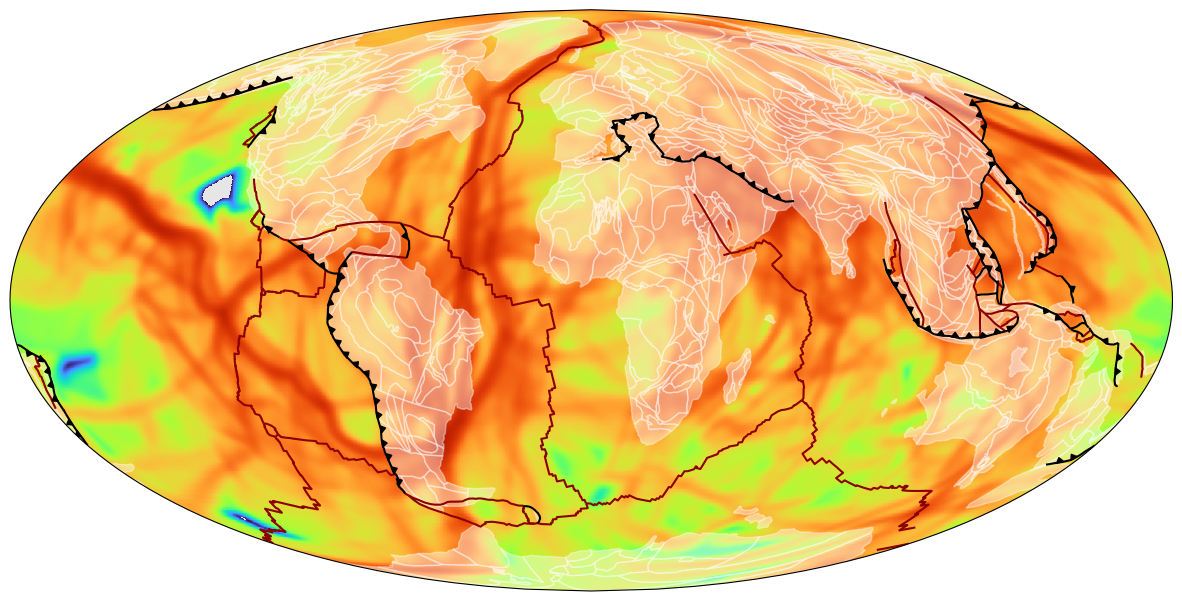

In [28]:
quantity = "mean"
reconstruction_time = 0
sample_grid = gplately.Raster(

    output_smooth_cumulative_subducted_water_filename.format(
        300,
        "Crust_bound", 
        quantity, 
        "Crust_bound".lower(), 
        reconstruction_time
    )
    
)

import copy 

proj = ccrs.Mollweide()
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111, projection=proj)
ax.set_global()

ax.imshow(np.array([[0.9,0.9],[0.9,0.9]]), extent=[-180,180,-180,180], cmap='gray', vmin=0, vmax=1,
          transform=ccrs.PlateCarree(), zorder=0)

data = sample_grid.data*1e6

lognorm_cmap = copy.copy(matplotlib.cm.get_cmap('turbo'))
lognorm_cmap.set_under(color='w', alpha=0)
im = ax.imshow(data, extent=extent_globe, origin='lower', cmap=lognorm_cmap, norm=mcolors.LogNorm(vmin=1e1, vmax=1e5), 
               transform=ccrs.PlateCarree(), interpolation='nearest')

gplot.time = reconstruction_time
# add_continents(ax,  facecolor='0.7', zorder=0)
gplot.plot_continents(ax, facecolor='w', edgecolor='w', alpha=0.4, zorder=2)
gplot.plot_ridges(ax, color='DarkRed', linewidth=1.5, zorder=2)
gplot.plot_transforms(ax, color='DarkRed', linewidth=1.5, zorder=2)
# add_quiver(ax, reconstruction_time, color='k', alpha=0.33, zorder=3)
gplot.plot_trenches(ax, color='k', zorder=2)
gplot.plot_subduction_teeth(ax, color='k', zorder=2)

# Optional cell - save grid folders to .zip files

In [21]:
from pathlib import Path
import shutil

components = [
    "crust_bound",
    "lithosphere_bottom",
    "mantle",
    "sediment_bound"
]

datasets = {
    "Muller2025_mean_subducted_water_300km": output_smooth_cumulative_subducted_water_grid_directory,
    "Muller2025_mean_slab_outflux_300km": output_smooth_cumulative_slab_outflux_grid_directory,
    "Muller2025_mean_stored_water_300km": output_smooth_cumulative_stored_water_grid_directory,
}

output_folder = Path("/Volumes/water2025/CO2_Review_Bundle/CO2_review_paper/Muller2025/Grids")
output_folder.mkdir(parents=True, exist_ok=True)

for component in components:

    for dataset_name, folder_template in datasets.items():

        folder = Path(folder_template.format(folder_name, distance_km, component, 'mean'))

        if not folder.exists():
            print(f"WARNING: Folder not found: {folder}")
            continue

        zip_path = output_folder / f"{dataset_name}_{component}"

        print(f"Zipping: {folder}")

        shutil.make_archive(
            base_name=str(zip_path),
            format="zip",
            root_dir=folder.parent,
            base_dir=folder.name,
        )

        print(f"Created: {zip_path}.zip")

print("\nDone!")

Zipping: /Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Cao_etal_2024/H2O/Grids/smoothed_cumulative_subducted_water_Muller2025/300km/crust_bound/mean
Created: /Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Muller2025/Grids/Muller2025_mean_subducted_water_300km_crust_bound.zip
Zipping: /Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Cao_etal_2024/H2O/Grids/smoothed_cumulative_slab_outflux_Muller2025/300km/crust_bound/mean
Created: /Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Muller2025/Grids/Muller2025_mean_slab_outflux_300km_crust_bound.zip
Zipping: /Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Cao_etal_2024/H2O/Grids/smoothed_cumulative_stored_water_Muller2025/300km/crust_bound/mean
Created: /Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Muller2025/Grids/Muller2025_mean_stored_water_300km_crust_bound.zip
Zipping: /Volumes/Carbon2025/CO2_Review_Bundle/CO2_review_paper/Cao_etal_2024/H2O/Grids/smoothed_cumulative_subducted_water_Muller202